# nb_02 — Light-curve property histograms

Goal (see `docs/SPEC_V01.md`, rough plan step 2): histograms for `nDiaSources`, and per-object
light-curve statistics — duration, cadence, amplitude — computed from the nested `diaSource`
column via `lsdb`'s `map_rows`. Works on the full HQ sample nb_01 wrote to `dp2_subset`
(`nDiaSources > 100`, ~399k objects spanning the whole `diaObject` collection) instead of
nb-v01's 5-field subset — there's no `field` column to split by anymore, so the plots below
treat the sample as a whole rather than stitching together per-partition/per-field panels.

**Resolves one of the spec's open questions.** `diaSource` carries both a difference-image
flux/mag (`psfFlux`/`psfMag` — noisy, sometimes negative → `NaN` mag) *and* an absolute,
calibrated science-image flux/mag (`scienceFlux`/`scienceMag` — a stable per-epoch baseline
value, confirmed against nb_01's subset). So the "diff fluxes aren't informative for
histograms" concern doesn't need a fix (no mag conversion, no Object-catalog crossmatch) —
`scienceMag` already works directly for amplitude-style statistics.

**Deferred to later, not attempted here:** the spec's rise/fall/peak-location stats for
detected transients need an actual transient-detection criterion first, which belongs with
the type-specific search work in the spec's "Specific types search" section, not a
general-purpose histogram notebook.

In [13]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lsdb
from datapaths import Datapaths

sys.path.insert(0, str(Path.cwd().parent / "src"))
from dataio import select_slice

from dask.distributed import Client

client = Client(n_workers=4, threads_per_worker=1, memory_limit="auto")

dp = Datapaths()
hq_cat = lsdb.open_catalog(dp["dp2_subset"] / "dia_object_lc_hq")
print(hq_cat.npartitions, "partitions")
hq_cat

/opt/lsst/software/stack/conda/envs/lsst-scipipe-12.3.0-exact/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35955 instead
  warnings.warn(


4445 partitions


,dec,diaObjectId,nDiaSources,ra,tract,diaObjectForcedSource,diaSource
npartitions=4445,,,,,,,
"Order: 5, Pixel: 6421",double[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],int64[pyarrow],"nested<band: [string], coord_dec: [double], co...","nested<band: [string], centroid_flag: [bool], ..."
...,...,...,...,...,...,...,...
"Order: 7, Pixel: 192510",...,...,...,...,...,...,...
"Order: 6, Pixel: 48912",...,...,...,...,...,...,...


## 0. Pick a slice of the HQ sample to explore

`hq_cat` above is lazy and spans the *whole* HQ collection (~399k objects across 4445
partitions) — too much to casually pull into memory or eyeball. `select_slice`
(`src/dataio/hq_sample.py`) gets you a small, concrete piece of it instead: either one
partition (fast, zero query cost, but an arbitrary sky-tile boundary) or a cone search around
a coordinate you pick (a more intuitive "give me this patch of sky", at the cost of a live
query). Toggle `SLICE_MODE` below. Nothing else in this notebook depends on this slice — the
histograms further down work on the whole sample — it's just something concrete to look at.

In [14]:
SLICE_MODE = "partition"  # "partition" or "cone_search"
PARTITION_INDEX = 200
CONE_RA, CONE_DEC, CONE_RADIUS_ARCSEC = 150.0, 2.0, 1800  # ~0.5 deg

slice_cat = select_slice(
    hq_cat,
    mode=SLICE_MODE,
    partition_index=PARTITION_INDEX,
    ra=CONE_RA,
    dec=CONE_DEC,
    radius_arcsec=CONE_RADIUS_ARCSEC,
)
slice_df = slice_cat.compute()
print(f"{SLICE_MODE}: {len(slice_df)} objects")
slice_df.drop(columns=["diaSource", "diaObjectForcedSource"]).head()

Computing Catalog:   0%|          | 0/1 [00:00<?, ?it/s]

partition: 42 objects


,dec,diaObjectId,nDiaSources,ra,tract
_healpix_29,,,,,
1918120089563200537,1.970019,788012974240432238,219,149.589554,9813
1918120134265825385,1.97887,788012974240432143,190,149.609931,9813
1918120169899973722,1.96894,788013042959908899,129,149.573488,9813
1918120360883513410,2.004394,788012974240432130,268,149.627216,9813
1918120552114538001,2.033824,788012974240432162,107,149.617547,9813


## 1. `nDiaSources` histogram

`nDiaSources` is a flat (non-nested) column, so this is a plain `.compute()` + `plt.hist` — no
`map_rows` needed. Reading it across the whole HQ sample (4445 partitions, ~399k objects)
takes about a minute even though it's only two flat columns — partition overhead, not data
volume. One combined histogram now, no per-field panel: the HQ sample has no `field` column,
and the point of this refactor is to treat it as one sample rather than stitch together
per-partition subplots.

In [15]:
flat_df = hq_cat[["diaObjectId", "nDiaSources"]].compute()
print(flat_df.shape)
flat_df["nDiaSources"].describe()

Computing Catalog:   0%|          | 0/4445 [00:00<?, ?it/s]

(398916, 2)


count      398916.0
mean     176.841305
std       91.476197
min           101.0
25%           116.0
50%           141.0
75%           203.0
max          1480.0
Name: nDiaSources, dtype: double[pyarrow]

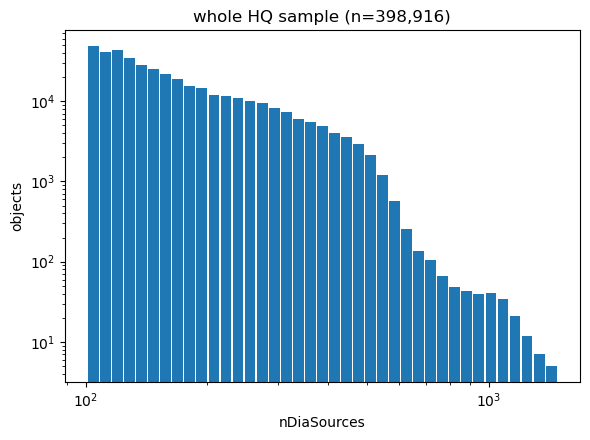

In [21]:
fig, ax = plt.subplots(figsize=(6, 4.5))

bins = np.logspace(np.log10(flat_df["nDiaSources"].min()), np.log10(flat_df["nDiaSources"].max()), 40)
ax.hist(flat_df["nDiaSources"], bins=bins, color="C0", rwidth=0.9)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("nDiaSources")
ax.set_ylabel("objects")
ax.set_title(f"whole HQ sample (n={len(flat_df):,})")

fig.tight_layout()

## 2. Per-object light-curve statistics via `map_partitions`

`catalog.map_partitions(func)` hands `func` a whole partition at a time as a
`nested_pandas.NestedFrame` (nested columns stay nested — `row["diaSource"]["midpointMjdTai"]`,
not `map_rows`'s flattened `row["diaSource.midpointMjdTai"]`), and returns a new **lazy**
`Catalog` — nothing runs until something downstream (like `write_catalog`) actually triggers a
compute, partition by partition, via Dask.

**Why not `map_rows` (nb-v01's choice)?** `map_rows` works the same way logically, but writing
its `append_columns=True` result directly hits an environment bug (misnamed margin-cache
index on reopen — nb_03 found this first). The workaround nb-v01 used was routing through
`.compute()` + `lsdb.from_dataframe()` before writing — which forces the *entire* ~399k-object
HQ sample into memory as one pandas frame, and makes the write all-or-nothing (a crash partway
loses everything, and there's no `resume=True` to fall back on since nothing's written until
that final materialized frame is done). `map_partitions` doesn't have the margin-cache bug, so
it can write straight from the lazy catalog with `resume=True` — see the flag markdown below.

**Vectorized, not a per-object Python loop.** The first version of this function looped
`for i in range(len(df))`, pulling one object's arrays out with `df.iloc[i]` at a time — this
type of loop is exactly what a `map_rows`/`map_partitions`-style API tempts you into, but a
`nested_pandas.NestedFrame`'s nested column is really just every epoch of every object in the
partition stacked together, and `.explode()` (same method nb_01 used) turns it into a plain
long-format table — one row per epoch — that ordinary pandas `groupby` aggregations handle for
every object in the partition at once. Checked against the original loop version on a real
75-partition, 2,713-object slice: identical results (to floating-point precision) at **~300x**
the speed (0.35s vs 105s) — at HQ scale that's the difference between roughly a minute and
roughly four and a half hours.

Two deliberate choices, both because bands don't share a cadence (same issue the spec flags
for color computation):
- **Duration and cadence gap use all bands combined** — they're about time sampling, not
  flux, so mixing bands is fine and matches "how long/how densely was this object monitored,
  period" rather than a per-band question.
- **Amplitude is computed per band** (`{band}_amp_p90p10`), *never* mixing bands — a g-band
  and r-band magnitude differ by the object's color, not by variability, so combining them
  would inflate "amplitude" with a color offset rather than measure real variation. We use
  the 10th-90th percentile range rather than min/max, per the spec's "robust-amplitude (with
  outliers discarded)" — a couple of noisy points at the tails don't blow up the estimate.

### Heavy-calculation flag

`map_partitions` below now runs once per partition across the *whole* HQ sample (~399k
objects, ~57x nb-v01's 5-field subset) — vectorized per-partition (see the section 2 markdown
above), so on the order of a minute total, not nb_04's multiband hours — extrapolating the
measured 0.35s/2,713-object rate to ~399k objects projects to roughly 50s, though that's not
been checked against the real full sample yet (only small slices — see `docs/changelog.md`).
Writes straight from the lazy `map_partitions` catalog with `resume=True` — no
`.compute()`/`from_dataframe()` roundtrip, and a crash partway through only loses the
partitions that hadn't been written yet, not the whole run.

**`resume=True` only knows which pixels exist on disk, not whether `lc_stats_partition`
changed.** If you edit the stats function and want a clean rebuild, delete
`dia_object_lc_hq_with_stats` first (or pass `overwrite=True` instead) — resuming onto a
directory from an older version of this function will silently keep the old values for
whatever pixels were already written.

`RUN_HEAVY_CALC` gates the whole thing; leave it `False` (the default) to read the stats back
from the already-registered `dia_object_lc_hq_with_stats` instead. **First time populating
this branch's registry:** set it `True` once so that collection actually exists before nb_03
tries to read it.

In [22]:
RUN_HEAVY_CALC = True

In [ ]:
BANDS = "ugrizy"


def lc_stats_partition(df):
    ids = df["diaObjectId"].to_numpy()

    exploded = df[["diaObjectId", "diaSource"]].explode("diaSource")
    exploded = exploded[["diaObjectId", "midpointMjdTai", "scienceMag", "band"]]

    # duration: order-independent (max - min), so no need to sort first
    dur = exploded.groupby("diaObjectId")["midpointMjdTai"].agg(["min", "max"])
    duration = (dur["max"] - dur["min"]).reindex(ids).to_numpy()

    # median cadence gap: sort within each object, diff, then median (skips the leading NaN
    # every group's first diff produces — same result as np.diff on the sorted array, since
    # that never produces a NaN to skip in the first place)
    sorted_t = exploded.sort_values(["diaObjectId", "midpointMjdTai"])
    gaps = sorted_t.groupby("diaObjectId")["midpointMjdTai"].diff()
    median_gap = gaps.groupby(sorted_t["diaObjectId"]).median().reindex(ids).to_numpy()

    df = df.copy()
    df["duration_days"] = duration
    df["median_cadence_gap_days"] = median_gap

    # per-band amplitude: finite scienceMag only, >=3 points required (else NaN)
    finite = exploded[np.isfinite(exploded["scienceMag"])]
    for b in BANDS:
        grp = finite.loc[finite["band"] == b].groupby("diaObjectId")["scienceMag"]
        counts = grp.size()
        amp = (grp.quantile(0.9) - grp.quantile(0.1)).where(counts >= 3)
        df[f"{b}_amp_p90p10"] = amp.reindex(ids).to_numpy()

    return df


with_stats_path = dp["dp2_subset"] / "dia_object_lc_hq_with_stats"
stat_cols = ["duration_days", "median_cadence_gap_days"] + [f"{b}_amp_p90p10" for b in BANDS]

if RUN_HEAVY_CALC:
    with_stats_cat = hq_cat.map_partitions(lc_stats_partition)
    with_stats_cat.write_catalog(with_stats_path, resume=True, create_thumbnail=False, progress_bar=False)
    print("wrote", with_stats_path)

    dp.register(
        name="dia_object_lc_hq_with_stats",
        type="dp2_subset",
        fmt="hats-collection",
        src_path=str(with_stats_path / "collection.properties"),
        tags=["nb02", "dp2", "diaObject", "lc-stats", "hq"],
        inputs=["dia_object_lc_hq"],
        notes=(
            "dia_object_lc_hq plus duration_days, median_cadence_gap_days (all bands) and "
            "{band}_amp_p90p10 (per band, scienceMag) columns, from nb_02."
        ),
        overwrite_history=True,
    )
    dp.print_paths(name="dia_object_lc_hq_with_stats")
else:
    print(f"RUN_HEAVY_CALC=False — skipping map_partitions/write/register; {with_stats_path} already up to date.")
client.close()

### Read the stats back

Reopen `dia_object_lc_hq_with_stats` regardless of whether `RUN_HEAVY_CALC` just wrote it or
it was already there — the histograms below only need the flat stat columns, not the nested
light curves.

In [7]:
with_stats_cat = lsdb.open_catalog(with_stats_path)
stats_df = with_stats_cat[stat_cols].compute()
print(stats_df.shape)
stats_df.describe()

FileNotFoundError: Failed to read HATS at location /home/shrra-ung/share/trieste/dia_object_lc_hq_with_stats

## 3. Histograms: duration and cadence gap

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(stats_df["duration_days"], bins=40, color="C2")
axes[0].set_xlabel("LC duration [days]")
axes[0].set_ylabel("objects")
axes[0].set_title("time between first and last diaSource")

gap = stats_df["median_cadence_gap_days"]
axes[1].hist(gap[gap > 0], bins=np.logspace(np.log10(max(gap[gap > 0].min(), 1e-3)), np.log10(gap.max()), 40), color="C3")
axes[1].set_xscale("log")
axes[1].set_xlabel("median cadence gap [days] (log)")
axes[1].set_title("all-band combined")

fig.tight_layout()

## 4. Histograms: per-band robust amplitude

One panel per band, so the very different sample sizes per band (`u` in particular — DP2's
LSSTCam observations spent little time there) stay visible rather than getting averaged away.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6))

for ax, b in zip(axes.flat, BANDS):
    values = stats_df[f"{b}_amp_p90p10"].dropna()
    if len(values) > 0:
        ax.hist(values, bins=30, color="C4")
    ax.set_title(f"{b}-band (n={len(values)})")
    ax.set_xlabel("P90-P10 scienceMag range")

fig.tight_layout()

## Next

`dia_object_lc_hq_with_stats` is registered (once `RUN_HEAVY_CALC=True` has been run at least
once on this branch) and has the light curves plus the new stat columns together — no join
needed. nb_03 picks up from here for color-mag/color-color plots.

Open questions carried forward, not resolved here:
- **Not yet run at full HQ scale.** The vectorized `map_partitions`/write/register pass was
  only checked against small slices in this session (see `docs/changelog.md`) — the ~50s
  extrapolated estimate in the heavy-calculation-flag markdown above is a projection, not a
  measurement.
- Whether P90-P10 is the right robustness choice, or something else (sigma-clipped std, MAD)
  would serve nb_04's period-finding work better as a shared amplitude definition.
- `median_cadence_gap_days` mixes bands; worth adding a per-band version once it's clear
  whether nb_04's period search wants combined or per-band cadence.
- Rewriting the whole collection every time a stat definition changes is fine at HQ-sample
  size (~399k objects) but won't scale to `dp2_filtered` (~300 GB) — worth revisiting whether
  `map_partitions` + `write_catalog` is still the right approach there, or whether stats should
  stay a separate, cheaply-regenerable side table once the target is the full collection.